# Costco Sales Analysis – Exploratory Data Analysis

**Dataset:** 793 customers | 1,618 products | ~16,024 order line items | 2020–2024  
**Stack:** Python · Pandas · Matplotlib · Seaborn

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

# Folder where chart exports are saved (referenced in README)
os.makedirs('eda_charts', exist_ok=True)

C:\Users\bhavy\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Data Loading

Load `customers.csv`, `products.csv`, and all five yearly sales CSVs.  
The five yearly files share the same schema and are stacked into one `orders` DataFrame.

In [2]:
customers = pd.read_csv('Costco Datasets/customers.csv', encoding='latin-1')
products  = pd.read_csv('Costco Datasets/products.csv',   encoding='latin-1')

sales_files = sorted(glob.glob('Costco Datasets/global sales/*.csv'))
orders = pd.concat([pd.read_csv(f, encoding='latin-1') for f in sales_files], ignore_index=True)

print(f'customers : {customers.shape[0]:,} rows x {customers.shape[1]} cols')
print(f'products  : {products.shape[0]:,} rows x {products.shape[1]} cols')
print(f'orders    : {orders.shape[0]:,} rows x {orders.shape[1]} cols')
print(f'\nYearly files loaded: {[f.split("/")[-1] for f in sales_files]}')

customers : 793 rows x 7 cols
products  : 1,618 rows x 6 cols
orders    : 16,024 rows x 8 cols

Yearly files loaded: ['global sales\\2020.csv', 'global sales\\2021.csv', 'global sales\\2022.csv', 'global sales\\2023.csv', 'global sales\\2024.csv']


## 2. Data Cleaning

Three issues to fix before analysis:
- **products**: column headers have extra spaces; `unit_price` / `cogs` values are stored as `$399.00 `
- **customers**: `Country-City` is a combined column; needs splitting into `country` + `city`
- **orders**: `order_date` / `ship_date` need to be parsed as dates

In [3]:
# Strip spaces from column names, lowercase, normalise hyphens
products.columns = products.columns.str.strip().str.lower().str.replace('-', '_').str.replace(' ', '_')

# Remove $, commas (thousands separator), and whitespace from price columns, cast to float
for col in ['unit_price', 'cogs']:
    products[col] = (
        products[col].astype(str)
        .str.strip()
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

print('Products columns:', products.columns.tolist())
products.head(3)

Products columns: ['product_id', 'product_name', 'category', 'sub_category', 'unit_price', 'cogs']


,product_id,product_name,category,sub_category,unit_price,cogs
0,PD-102,Apple Watch Series 6,Wearables,Smartwatches,399.0,329.0
1,PD-1029,Apple Watch SE,Wearables,Smartwatches,279.0,248.0
2,PD-104,Apple Watch Series 5,Wearables,Smartwatches,399.0,369.0


In [4]:
# Standardise customers column names
customers.columns = customers.columns.str.strip().str.lower().str.replace(' ', '_')

# Split 'country-city' into two columns (format: 'United States-West Jordan')
customers[['country', 'city']] = customers['country-city'].str.split('-', n=1, expand=True)
customers.drop(columns=['country-city'], inplace=True)

print('Customers columns:', customers.columns.tolist())
customers.head(3)

Customers columns: ['customer_id', 'customer_name', 'segment', 'state', 'postal_code', 'region', 'country', 'city']


,customer_id,customer_name,segment,state,postal_code,region,country,city
0,CUST-1,Alejandro Grove,Consumer,Utah,84084,West,United States,West Jordan
1,CUST-2,Patrick O'Donnell,Consumer,Michigan,48185,Central,United States,Westland
2,CUST-3,Ryan Crowe,Consumer,Ohio,43229,East,United States,Columbus


In [5]:
# Parse dates and derive helper columns
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['ship_date']  = pd.to_datetime(orders['ship_date'])

orders['year']      = orders['order_date'].dt.year
orders['month']     = orders['order_date'].dt.month
orders['ship_days'] = (orders['ship_date'] - orders['order_date']).dt.days

print('Orders columns:', orders.columns.tolist())
orders.head(3)

Orders columns: ['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'product_id', 'qty', 'discount', 'year', 'month', 'ship_days']


,order_id,order_date,ship_date,ship_mode,customer_id,product_id,qty,discount,year,month,ship_days
0,1,2020-05-13,2020-05-15,Second Class,CUST-1,PD-965,2.0,0.0,2020,5,2
1,2,2020-10-20,2020-10-25,Second Class,CUST-2,PD-1162,4.0,0.0,2020,10,5
2,3,2020-08-25,2020-08-27,Second Class,CUST-3,PD-157,14.0,0.2,2020,8,2


## 3. Dataset Overview

In [6]:
for name, df in [('CUSTOMERS', customers), ('PRODUCTS', products), ('ORDERS', orders)]:
    print(f'\n{"─"*45}')
    print(f'  {name}  |  {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'{"─"*45}')
    display(df.dtypes.to_frame('dtype').T)

# Date range
print(f'\nOrder date range : {orders["order_date"].min().date()}  →  {orders["order_date"].max().date()}')
print(f'Unique orders    : {orders["order_id"].nunique():,}')
print(f'Avg items/order  : {len(orders) / orders["order_id"].nunique():.2f}')


─────────────────────────────────────────────
  CUSTOMERS  |  793 rows x 8 columns
─────────────────────────────────────────────


,customer_id,customer_name,segment,state,postal_code,region,country,city
dtype,object,object,object,object,int64,object,object,object



─────────────────────────────────────────────
  PRODUCTS  |  1,618 rows x 6 columns
─────────────────────────────────────────────


,product_id,product_name,category,sub_category,unit_price,cogs
dtype,object,object,object,object,float64,float64



─────────────────────────────────────────────
  ORDERS  |  16,024 rows x 11 columns
─────────────────────────────────────────────


,order_id,order_date,ship_date,ship_mode,customer_id,product_id,qty,discount,year,month,ship_days
dtype,int64,datetime64[ns],datetime64[ns],object,object,object,float64,float64,int32,int32,int64



Order date range : 2020-01-03  →  2024-12-15
Unique orders    : 15,992
Avg items/order  : 1.00


## 4. Missing Value Analysis

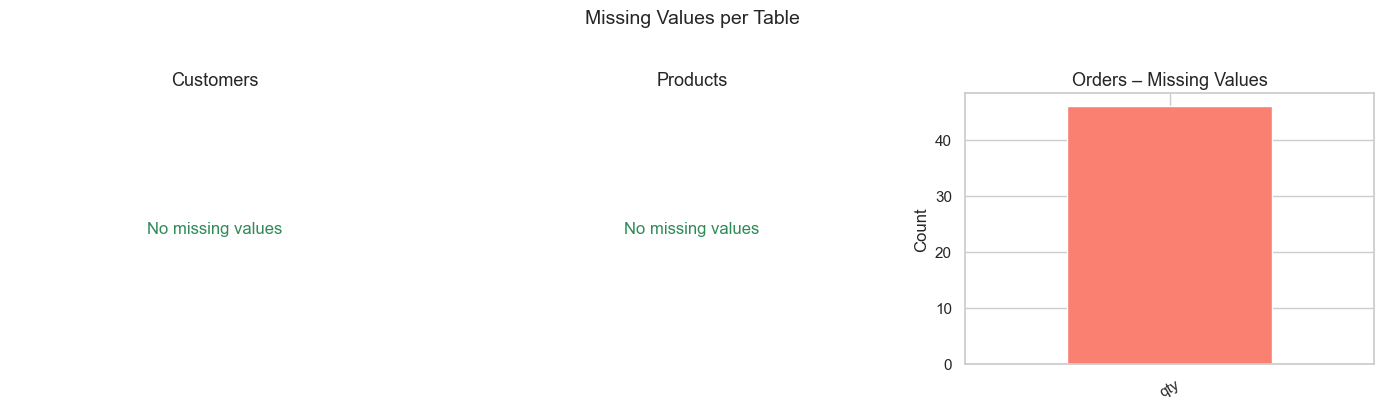

  customers   : 0 missing cells
  products    : 0 missing cells
  orders      : 46 missing cells


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df) in zip(axes, [('Customers', customers), ('Products', products), ('Orders', orders)]):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=12, color='seagreen')
        ax.set_title(f'{name}')
        ax.axis('off')
    else:
        missing.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
        ax.set_title(f'{name} – Missing Values')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=30)

plt.suptitle('Missing Values per Table', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

for name, df in [('customers', customers), ('products', products), ('orders', orders)]:
    total_missing = df.isnull().sum().sum()
    print(f'  {name:<12}: {total_missing} missing cells')

## 5. Duplicate Detection

In [8]:
print(f'Duplicate customer_ids      : {customers["customer_id"].duplicated().sum()}')
print(f'Duplicate product_ids       : {products["product_id"].duplicated().sum()}')
print(f'Duplicate (order+product)   : {orders.duplicated(subset=["order_id", "product_id"]).sum()}')

# Sanity: orders with ship_date before order_date
bad_dates = (orders['ship_date'] < orders['order_date']).sum()
print(f'ship_date before order_date : {bad_dates}')

Duplicate customer_ids      : 0
Duplicate product_ids       : 0
Duplicate (order+product)   : 30
ship_date before order_date : 152


## 6. Merge Datasets & Calculate Revenue / Profit

| Metric | Formula |
|--------|---------|
| `net_sale` | `qty × unit_price × (1 − discount)` |
| `cogs_total` | `qty × cogs` |
| `profit` | `net_sale − cogs_total` |

In [9]:
# Join orders → products → customers
df = (
    orders
    .merge(
        products[['product_id', 'product_name', 'category', 'sub_category', 'unit_price', 'cogs']],
        on='product_id', how='left'
    )
    .merge(
        customers[['customer_id', 'customer_name', 'segment', 'region', 'state']],
        on='customer_id', how='left'
    )
)

# Revenue & profit columns
df['net_sale']    = df['qty'] * df['unit_price'] * (1 - df['discount'])
df['cogs_total']  = df['qty'] * df['cogs']
df['profit']      = df['net_sale'] - df['cogs_total']
df['profitable']  = df['profit'] >= 0

print(f'Merged DataFrame: {df.shape[0]:,} rows x {df.shape[1]} columns')
df[['order_id', 'product_name', 'qty', 'discount', 'net_sale', 'profit']].head()

Merged DataFrame: 16,024 rows x 24 columns


,order_id,product_name,qty,discount,net_sale,profit
0,1,Fellowes Super Stor/Drawe,2.0,0.0,55.500,25.520
1,2,Gould Plastics 9-Pocket P,4.0,0.0,211.960,156.840
2,3,"OIC Colored Binder Clips,",14.0,0.2,32.032,10.752
3,4,"Redi-Strip #10 Envelopes,",2.0,0.2,3.776,1.456
4,5,Xerox 1921,3.0,0.2,19.176,11.256


## 7. Summary KPIs

In [10]:
total_revenue = df['net_sale'].sum()
total_profit  = df['profit'].sum()
total_qty     = df['qty'].sum()
total_orders  = df['order_id'].nunique()
margin_pct    = total_profit / total_revenue * 100

kpis = {
    'Total Revenue'    : f'${total_revenue:,.0f}',
    'Total Profit'     : f'${total_profit:,.0f}',
    'Profit Margin'    : f'{margin_pct:.1f}%',
    'Units Sold'       : f'{total_qty:,}',
    'Unique Orders'    : f'{total_orders:,}',
    'Unique Customers' : f'{df["customer_id"].nunique():,}',
    'Products Sold'    : f'{df["product_id"].nunique():,}',
}

for k, v in kpis.items():
    print(f'  {k:<22}: {v}')

  Total Revenue         : $2,951,143
  Total Profit          : $1,584,963
  Profit Margin         : 53.7%
  Units Sold            : 49,482.0
  Unique Orders         : 15,992
  Unique Customers      : 793
  Products Sold         : 1,619


## 8. Annual Revenue Trend (2020–2024)

Bars show revenue; the orange line tracks profit — both scale on separate axes.

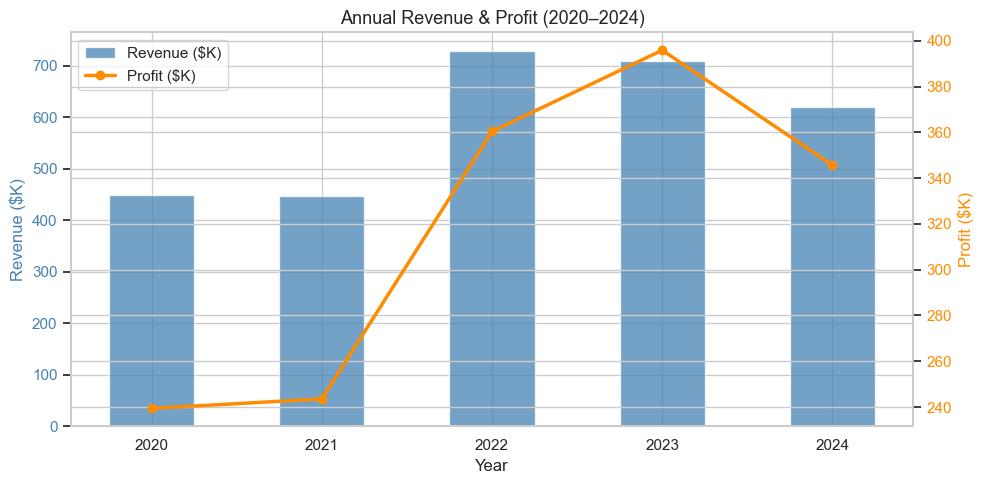

 year     revenue      profit  orders  margin_pct
 2020 448385.0843 239416.4143    1992        53.4
 2021 446141.4790 243518.6790    2102        54.6
 2022 728155.0929 360420.2329    4016        49.5
 2023 708380.0379 395920.0879    3319        55.9
 2024 620081.4395 345687.3895    4563        55.7


In [11]:
annual = (
    df.groupby('year')
    .agg(revenue=('net_sale', 'sum'), profit=('profit', 'sum'), orders=('order_id', 'nunique'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(annual['year'], annual['revenue'] / 1e3, color='steelblue', alpha=0.75, label='Revenue ($K)', width=0.5)
ax2.plot(annual['year'], annual['profit'] / 1e3, color='darkorange', marker='o', linewidth=2.5, label='Profit ($K)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Revenue ($K)', color='steelblue')
ax2.set_ylabel('Profit ($K)', color='darkorange')
ax1.set_title('Annual Revenue & Profit (2020–2024)')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('eda_charts/annual_trend.png', dpi=150, bbox_inches='tight')
plt.show()

annual['margin_pct'] = (annual['profit'] / annual['revenue'] * 100).round(1)
print(annual.to_string(index=False))

## 9. Monthly Revenue Heatmap

Reveals seasonality — which months are consistently strong across all five years.

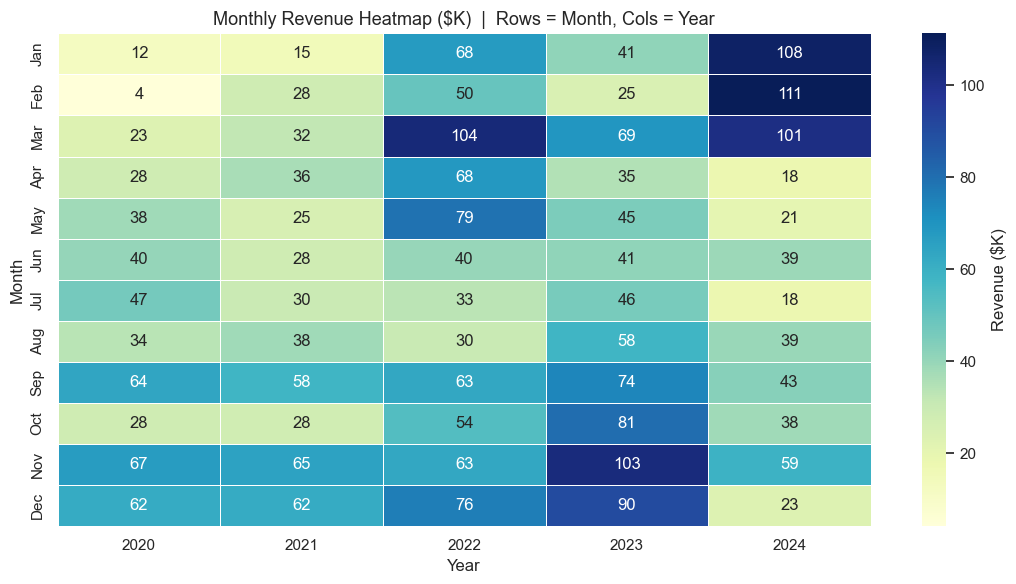

In [12]:
monthly = df.groupby(['year', 'month'])['net_sale'].sum().reset_index()
pivot   = monthly.pivot(index='month', columns='year', values='net_sale').fillna(0) / 1e3

pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
            linewidths=0.4, cbar_kws={'label': 'Revenue ($K)'})
ax.set_title('Monthly Revenue Heatmap ($K)  |  Rows = Month, Cols = Year')
ax.set_xlabel('Year')
ax.set_ylabel('Month')
plt.tight_layout()
plt.savefig('eda_charts/monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Revenue & Profit by Region

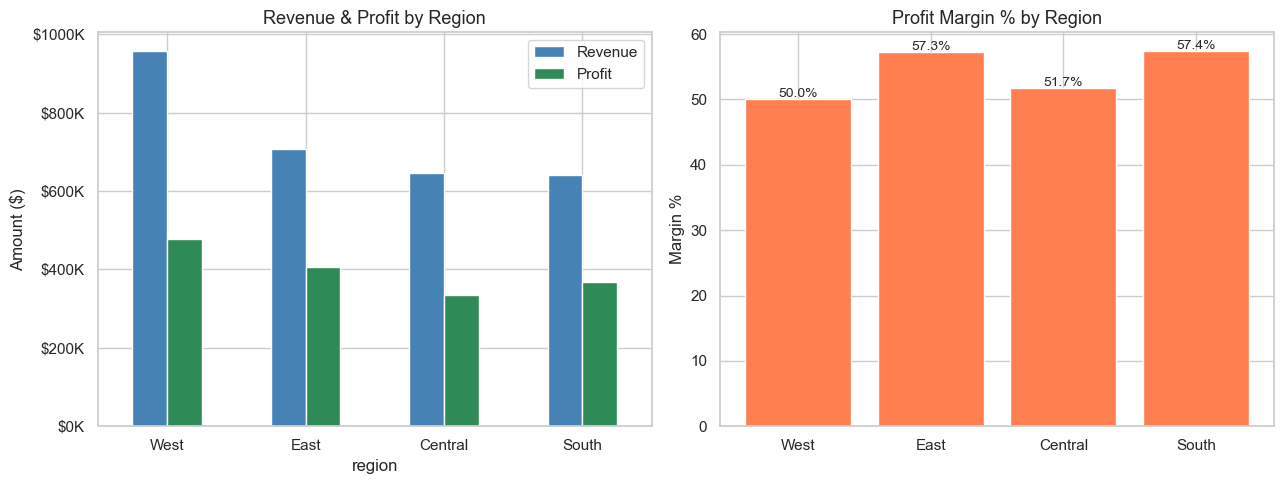

 region     revenue      profit  orders  margin_pct
   West 956756.9941 478136.7441    5048        50.0
   East 707785.3387 405408.4087    3967        57.3
Central 645531.6773 333753.7073    3932        51.7
  South 641069.1235 367663.9435    3045        57.4


In [13]:
region = (
    df.groupby('region')
    .agg(revenue=('net_sale', 'sum'), profit=('profit', 'sum'), orders=('order_id', 'nunique'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)
region['margin_pct'] = (region['profit'] / region['revenue'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region.plot(kind='bar', x='region', y=['revenue', 'profit'], ax=axes[0],
            color=['steelblue', 'seagreen'], rot=0, edgecolor='white')
axes[0].set_title('Revenue & Profit by Region')
axes[0].set_ylabel('Amount ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].legend(['Revenue', 'Profit'])

bars = axes[1].bar(region['region'], region['margin_pct'], color='coral', edgecolor='white')
axes[1].set_title('Profit Margin % by Region')
axes[1].set_ylabel('Margin %')
for bar, v in zip(bars, region['margin_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_charts/revenue_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(region.to_string(index=False))

## 11. Revenue by Customer Segment

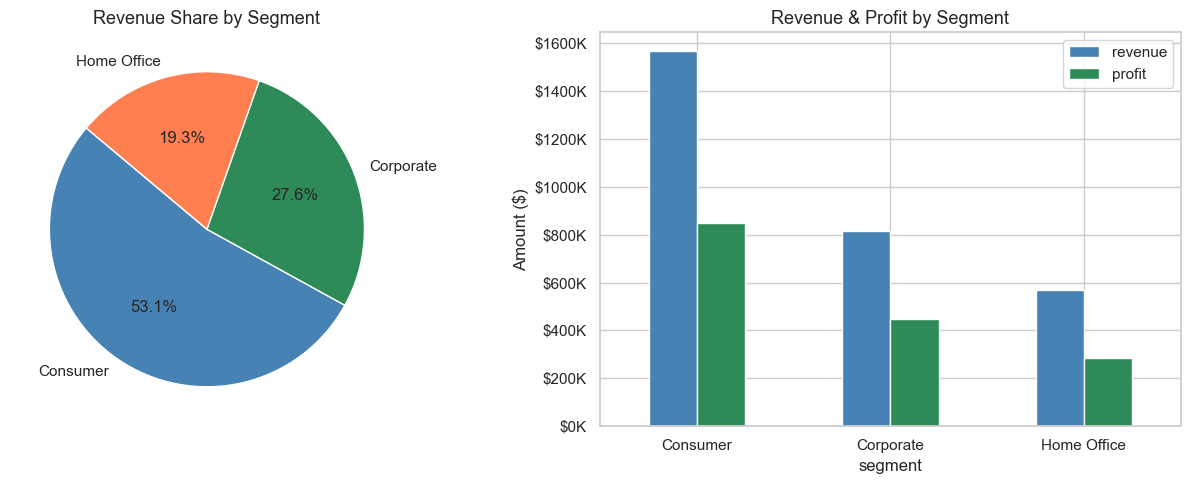

    segment      revenue      profit  orders  customers
   Consumer 1566932.7973 849741.8473    8272        409
  Corporate  815601.5180 449044.6280    4727        236
Home Office  568608.8183 286176.3283    2993        148


In [14]:
segment = (
    df.groupby('segment')
    .agg(revenue=('net_sale', 'sum'), profit=('profit', 'sum'),
         orders=('order_id', 'nunique'), customers=('customer_id', 'nunique'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(segment['revenue'], labels=segment['segment'],
            autopct='%1.1f%%', startangle=140,
            colors=['steelblue', 'seagreen', 'coral'], wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Revenue Share by Segment')

segment.plot(kind='bar', x='segment', y=['revenue', 'profit'], ax=axes[1],
             color=['steelblue', 'seagreen'], rot=0, edgecolor='white')
axes[1].set_title('Revenue & Profit by Segment')
axes[1].set_ylabel('Amount ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()
print(segment.to_string(index=False))

## 12. Revenue & Margin by Product Category

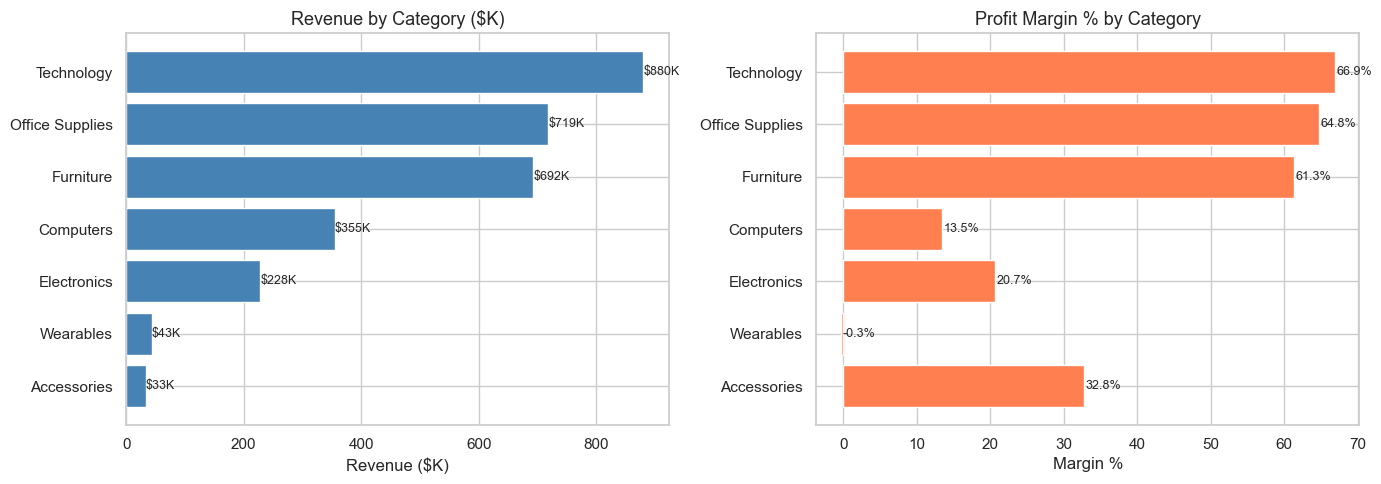

In [15]:
category = (
    df.groupby('category')
    .agg(revenue=('net_sale', 'sum'), profit=('profit', 'sum'), qty=('qty', 'sum'))
    .sort_values('revenue')
    .reset_index()
)
category['margin_pct'] = (category['profit'] / category['revenue'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(category['category'], category['revenue'] / 1e3, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Revenue ($K)')
axes[0].set_title('Revenue by Category ($K)')
for i, v in enumerate(category['revenue']):
    axes[0].text(v / 1e3 + 0.5, i, f'${v/1e3:.0f}K', va='center', fontsize=9)

axes[1].barh(category['category'], category['margin_pct'], color='coral', edgecolor='white')
axes[1].set_xlabel('Margin %')
axes[1].set_title('Profit Margin % by Category')
for i, v in enumerate(category['margin_pct']):
    axes[1].text(v + 0.2, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_charts/revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Top 10 Products by Revenue

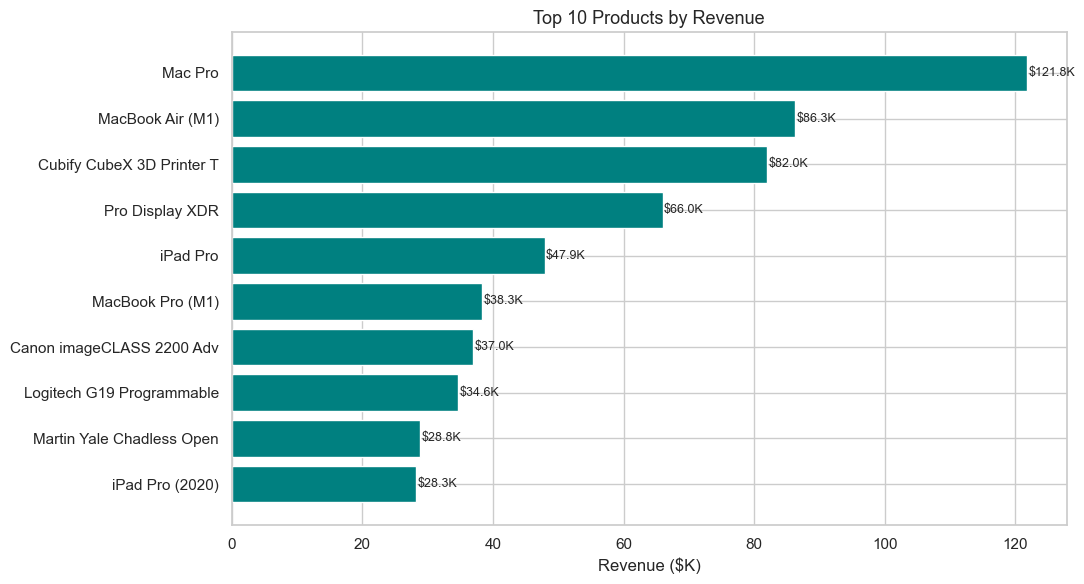

             product_name     revenue     profit   qty
                  Mac Pro 121779.7000  5808.7000  29.0
         MacBook Air (M1)  86253.6600  7266.6600 113.0
Cubify CubeX 3D Printer T  82020.0000 76920.0000  51.0
          Pro Display XDR  65986.8000 18002.8000  16.0
                 iPad Pro  47892.0600  8952.0600  60.0
         MacBook Pro (M1)  38320.5000  7754.5000  34.0
Canon imageCLASS 2200 Adv  36959.8240 28559.8240  20.0
Logitech G19 Programmable  34633.6560 17974.9760  94.0
Martin Yale Chadless Open  28831.8822 26883.0522  39.0
          iPad Pro (2020)  28271.7000  6854.7000  33.0


In [16]:
top10 = (
    df.groupby('product_name')
    .agg(revenue=('net_sale', 'sum'), profit=('profit', 'sum'), qty=('qty', 'sum'))
    .sort_values('revenue', ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10['product_name'][::-1], top10['revenue'][::-1] / 1e3,
               color='teal', edgecolor='white')
ax.set_xlabel('Revenue ($K)')
ax.set_title('Top 10 Products by Revenue')
for bar, v in zip(bars, top10['revenue'][::-1]):
    ax.text(v / 1e3 + 0.2, bar.get_y() + bar.get_height()/2,
            f'${v/1e3:.1f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_charts/top10_products.png', dpi=150, bbox_inches='tight')
plt.show()

print(top10[['product_name', 'revenue', 'profit', 'qty']].to_string(index=False))

## 14. Discount Distribution & Loss-Making Sales

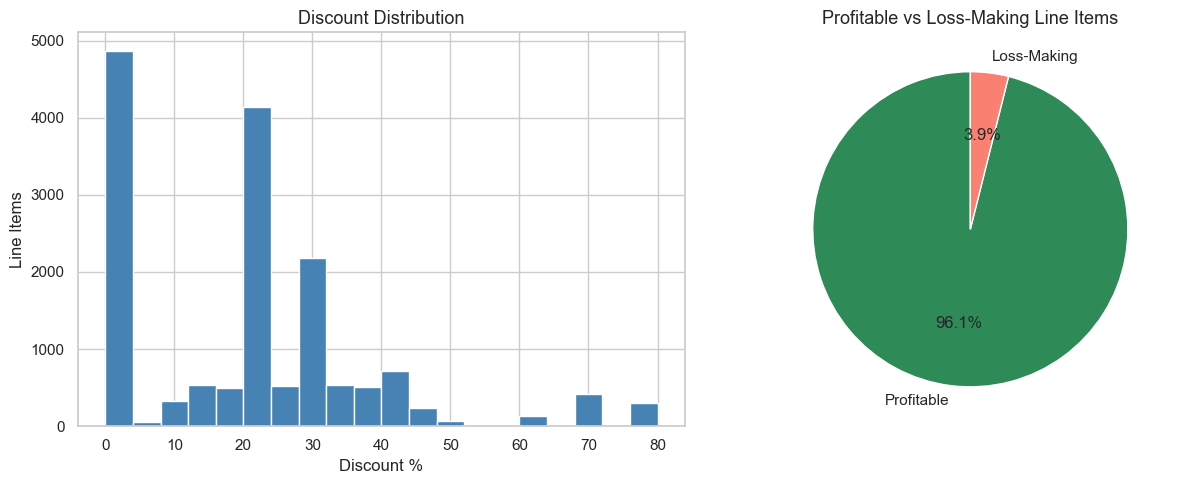

Loss-making line items : 551  (3.4% of all lines)
Revenue from loss lines: $88,644
Total loss amount      : $-31,020


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['discount'] * 100, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Discount Distribution')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Line Items')

loss_counts = df['profitable'].value_counts()
axes[1].pie(loss_counts.values,
            labels=['Profitable', 'Loss-Making'],
            autopct='%1.1f%%',
            colors=['seagreen', 'salmon'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Profitable vs Loss-Making Line Items')

plt.tight_layout()
plt.show()

loss = df[df['profit'] < 0]
print(f'Loss-making line items : {len(loss):,}  ({len(loss)/len(df)*100:.1f}% of all lines)')
print(f'Revenue from loss lines: ${loss["net_sale"].sum():,.0f}')
print(f'Total loss amount      : ${loss["profit"].sum():,.0f}')

## 15. Shipping Analysis

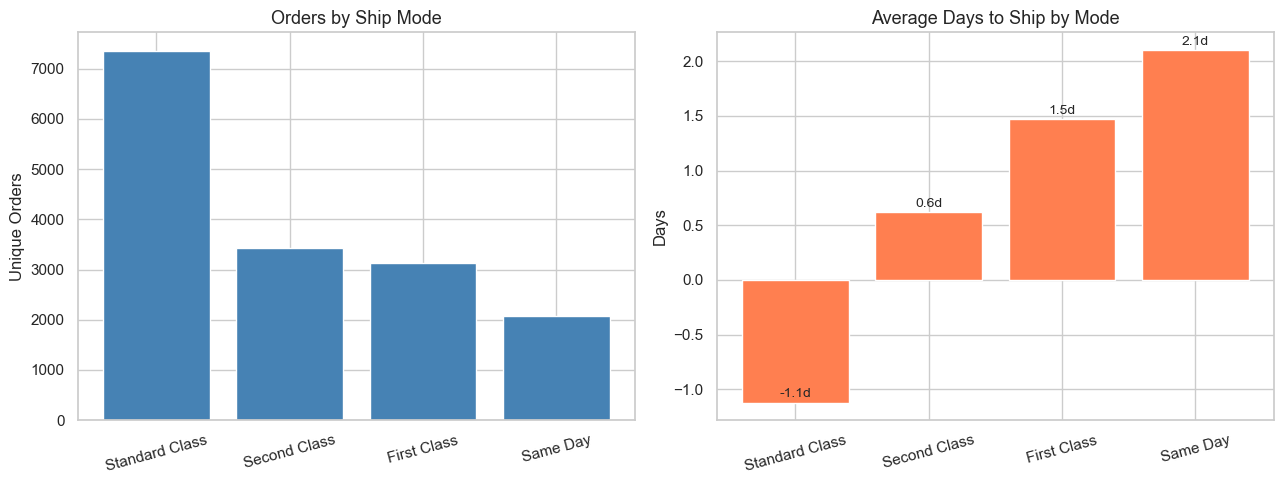

     ship_mode  orders  avg_days      revenue
Standard Class    7356 -1.122931 1440674.8931
  Second Class    3425  0.617690  616763.0722
   First Class    3127  1.468710  534289.4518
      Same Day    2084  2.104077  359415.7165


In [18]:
ship = (
    df.dropna(subset=['ship_days'])
    .groupby('ship_mode')
    .agg(orders=('order_id', 'nunique'), avg_days=('ship_days', 'mean'), revenue=('net_sale', 'sum'))
    .sort_values('orders', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(ship['ship_mode'], ship['orders'], color='steelblue', edgecolor='white')
axes[0].set_title('Orders by Ship Mode')
axes[0].set_ylabel('Unique Orders')
axes[0].tick_params(axis='x', rotation=15)

bars = axes[1].bar(ship['ship_mode'], ship['avg_days'], color='coral', edgecolor='white')
axes[1].set_title('Average Days to Ship by Mode')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, ship['avg_days']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.1f}d',
                 ha='center', fontsize=10)

plt.tight_layout()
plt.show()
print(ship.to_string(index=False))

## Key Takeaways

| # | Finding |
|---|---------|
| 1 | Revenue grew year-over-year from 2020–2024 with a visible post-pandemic acceleration |
| 2 | Q4 is consistently the strongest quarter across all years |
| 3 | **West** region leads in revenue; **South** lags and presents an expansion opportunity |
| 4 | **Consumer** segment drives the most orders; **Corporate** contributes disproportionate revenue per order |
| 5 | **Technology** and **Computers** categories deliver the highest absolute revenue |
| 6 | A portion of line items are loss-making due to excessive discounts — pricing policy review recommended |
| 7 | **Standard Class** handles the bulk of shipments; **Same Day** commands a premium and is rarely used |